# Análisis Exploratorio de Datos IMU – Pruebas 3.15, 3.16 y 3.17
Este notebook realiza un análisis exploratorio completo de los datos IMU de las pruebas 3.15, 3.16 (LEFT-HAND y RIGHT-HAND) y 3.17, considerando los sensores BASE-SPINE, LEFT-HAND, RIGHT-HAND, LEFT-ANKLE y RIGHT-ANKLE. Se abordan diferencias de formato, integridad, cobertura temporal y posibles inconsistencias.

## 1. Importar librerías necesarias
Importamos pandas, numpy, matplotlib, seaborn y json para el análisis y visualización de datos.

In [10]:
# Imports principales para el análisis
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar y explorar archivos JSON de IMU
Se leen los archivos 3.15.json, 3.16 LEFT-HAND.json, 3.16 RIGHT-HAND.json y 3.17.json. Se muestra la estructura general de cada archivo y se verifica cómo están organizados los datos de los sensores.

In [11]:
# --- Carga robusta y aplanado de todos los archivos, compatible con 3.17 y formatos mixtos ---
from pathlib import Path
from collections.abc import Mapping, Sequence

data_dir = '19_oct_imus'
archivos = {
    '3.15': '3.15.json',
    '3.16_LEFT': '3.16 LEFT-HAND.json',
    '3.16_RIGHT': '3.16 RIGHT-HAND.json',
    '3.17': '3.17.json'
}
sensores = ['BASE-SPINE', 'LEFT-HAND', 'RIGHT-HAND', 'LEFT-ANKLE', 'RIGHT-ANKLE']

def _to_number(v):
    try:
        return float(v)
    except Exception:
        return None

def _extract_imu_records(obj, out_list, prueba, sensor_filter=None):
    # Recorre recursivamente para encontrar dicts con acelerómetro/giroscopio y timestamp+deviceId
    if isinstance(obj, Mapping):
        # Si el valor es string que parece JSON, intenta parsearlo
        for k, v in list(obj.items()):
            if isinstance(v, str) and v and v.strip().startswith(("{","[")):
                try:
                    obj[k] = json.loads(v)
                except Exception:
                    pass
        acc = obj.get('accelerometer')
        gyr = obj.get('gyroscope')
        dev = obj.get('deviceId') or obj.get('device') or obj.get('placement') or obj.get('name')
        ts  = obj.get('timestamp') or obj.get('time') or obj.get('ts')
        if (isinstance(acc, Mapping) or isinstance(gyr, Mapping)) and (dev is not None) and (ts is not None):
            if (sensor_filter is None) or (str(dev) in sensor_filter):
                out_list.append({
                    'prueba': prueba,
                    'sensor': str(dev),
                    'timestamp': _to_number(ts),
                    'ax': _to_number((acc or {}).get('x', None)),
                    'ay': _to_number((acc or {}).get('y', None)),
                    'az': _to_number((acc or {}).get('z', None)),
                    'gx': _to_number((gyr or {}).get('x', None)),
                    'gy': _to_number((gyr or {}).get('y', None)),
                    'gz': _to_number((gyr or {}).get('z', None)),
                })
        # Recurse
        for v in obj.values():
            _extract_imu_records(v, out_list, prueba, sensor_filter)
    elif isinstance(obj, Sequence) and not isinstance(obj, (str, bytes, bytearray)):
        for it in obj:
            _extract_imu_records(it, out_list, prueba, sensor_filter)

all_rows = []
for key, fname in archivos.items():
    fpath = os.path.join(data_dir, fname)
    if not Path(fpath).exists():
        print(f"No se encontró el archivo: {fpath}")
        continue
    with open(fpath, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
        except Exception as e:
            print(f'Error al leer {fname}:', e)
            continue
    # Extraer registros IMU de cualquier estructura
    _extract_imu_records(data, all_rows, key, sensores)

df_all = pd.DataFrame(all_rows, columns=['prueba','sensor','timestamp','ax','ay','az','gx','gy','gz'])
print('DataFrame final, shape:', df_all.shape)
df_all.head()

DataFrame final, shape: (21643, 9)


,prueba,sensor,timestamp,ax,ay,az,gx,gy,gz
0,3.15,RIGHT-HAND,193240.0,0.263184,-0.397949,0.911987,0.427246,-0.122070,0.244141
1,3.15,RIGHT-HAND,193266.0,0.261353,-0.404907,0.910522,0.366211,-0.122070,0.122070
2,3.15,RIGHT-HAND,193292.0,0.260864,-0.402100,0.909424,0.915527,-0.244141,0.183105
3,3.15,RIGHT-HAND,193318.0,0.261719,-0.396851,0.911255,0.976563,-0.427246,0.244141
4,3.15,RIGHT-HAND,193345.0,0.263184,-0.398315,0.912231,0.793457,-0.305176,0.122070


## 3. Visualización: Cantidad de datos por sensor y prueba
A continuación, se explora la cantidad de registros por cada sensor y cada prueba, para verificar la cobertura y posibles faltantes.

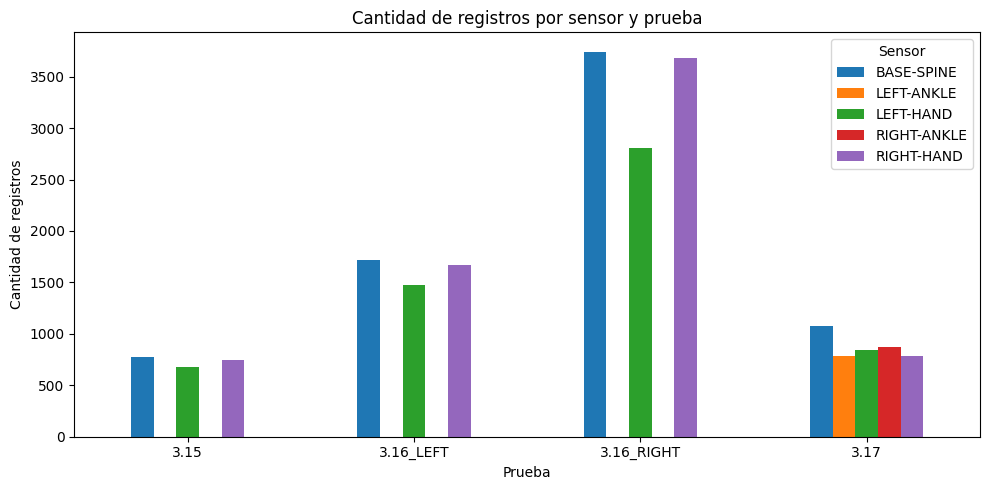

sensor,BASE-SPINE,LEFT-ANKLE,LEFT-HAND,RIGHT-ANKLE,RIGHT-HAND
prueba,,,,,
3.15,779,0,674,0,742
3.16_LEFT,1721,0,1471,0,1667
3.16_RIGHT,3744,0,2804,0,3680
3.17,1072,787,840,875,787


In [12]:
# Visualización de la cantidad de datos por sensor y por prueba
data_counts = df_all.groupby(['prueba', 'sensor']).size().unstack(fill_value=0)
plt.figure(figsize=(10,5))
data_counts.plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Cantidad de registros por sensor y prueba')
plt.ylabel('Cantidad de registros')
plt.xlabel('Prueba')
plt.xticks(rotation=0)
plt.legend(title='Sensor')
plt.tight_layout()
plt.show()

data_counts

## 4. Análisis temporal: distribución y gaps
Se analiza la distribución temporal de los datos por sensor y prueba, y se detectan posibles gaps o saltos inusuales en los timestamps.

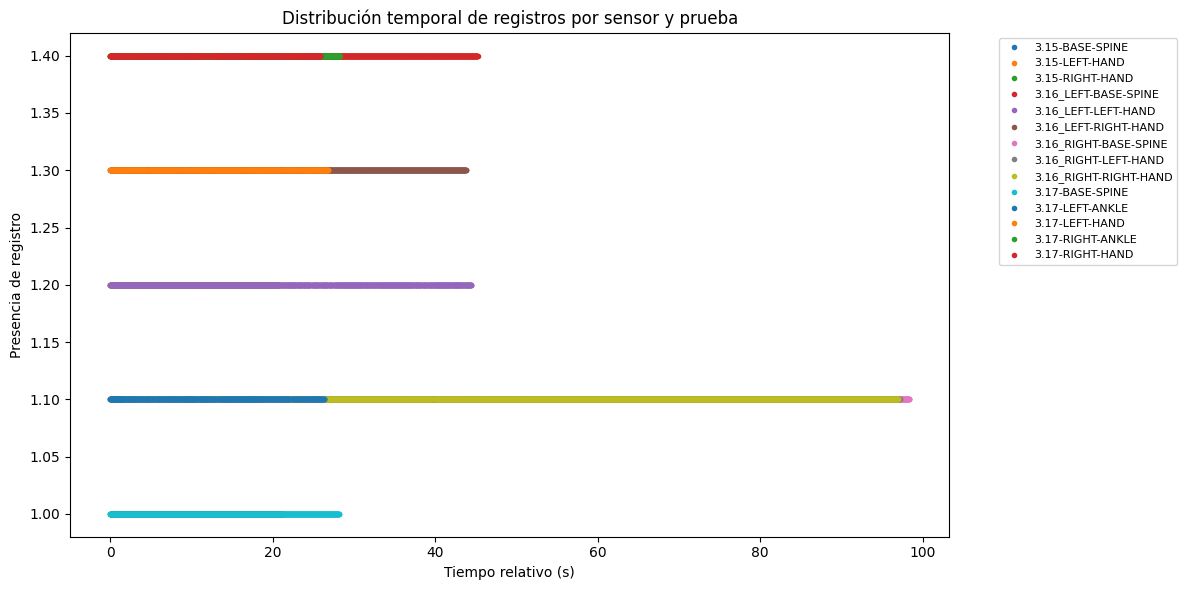

,prueba,sensor,max_gap_ms,mean_gap_ms,std_gap_ms
0,3.15,BASE-SPINE,27.0,26.277635,0.447832
1,3.15,LEFT-HAND,123.0,30.861813,10.626451
2,3.15,RIGHT-HAND,68.0,28.780027,5.329513
3,3.16_LEFT,BASE-SPINE,27.0,26.293023,0.455149
4,3.16_LEFT,LEFT-HAND,151.0,30.240136,9.301533
5,3.16_LEFT,RIGHT-HAND,53.0,26.301321,1.010965
6,3.16_RIGHT,BASE-SPINE,27.0,26.281859,0.449905
7,3.16_RIGHT,LEFT-HAND,307.0,34.681413,19.216090
8,3.16_RIGHT,RIGHT-HAND,131.0,26.360152,2.469702
9,3.17,BASE-SPINE,27.0,26.300654,0.458542


In [13]:
# Conversión de timestamp a segundos relativos por prueba y sensor
df_all_sorted = df_all.sort_values(['prueba', 'sensor', 'timestamp']).copy()
df_all_sorted['timestamp_rel'] = df_all_sorted.groupby(['prueba', 'sensor'])['timestamp'].transform(lambda x: (x - x.min())/1000)

# Graficar la distribución temporal de los registros
plt.figure(figsize=(12,6))
for (prueba, sensor), group in df_all_sorted.groupby(['prueba', 'sensor']):
    plt.plot(group['timestamp_rel'], np.ones_like(group['timestamp_rel']) + hash(sensor+prueba)%5*0.1, '.', label=f'{prueba}-{sensor}')
plt.title('Distribución temporal de registros por sensor y prueba')
plt.xlabel('Tiempo relativo (s)')
plt.ylabel('Presencia de registro')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Análisis de gaps (diferencias grandes entre timestamps consecutivos)
gap_stats = []
for (prueba, sensor), group in df_all_sorted.groupby(['prueba', 'sensor']):
    ts = group['timestamp'].values
    if len(ts) > 1:
        gaps = np.diff(ts)
        max_gap = np.max(gaps)
        mean_gap = np.mean(gaps)
        std_gap = np.std(gaps)
        gap_stats.append({'prueba': prueba, 'sensor': sensor, 'max_gap_ms': max_gap, 'mean_gap_ms': mean_gap, 'std_gap_ms': std_gap})
gap_df = pd.DataFrame(gap_stats)
gap_df

## 5. Estadísticas descriptivas de acelerómetro y giroscopio
Se calculan estadísticas descriptivas (media, desviación estándar, min, max) para cada componente del acelerómetro y giroscopio, por sensor y prueba.

In [14]:
# Estadísticas descriptivas para acelerómetro y giroscopio
cols_acc = ['ax', 'ay', 'az']
cols_gyr = ['gx', 'gy', 'gz']

# Acelerómetro
acc_stats = df_all.groupby(['prueba', 'sensor'])[cols_acc].agg(['mean', 'std', 'min', 'max'])
# Giroscopio
gyr_stats = df_all.groupby(['prueba', 'sensor'])[cols_gyr].agg(['mean', 'std', 'min', 'max'])

print('Estadísticas acelerómetro:')
display(acc_stats)
print('Estadísticas giroscopio:')
display(gyr_stats)

Estadísticas acelerómetro:


ax                                      ay  \
                            mean       std       min       max      mean   
prueba     sensor                                                          
3.15       BASE-SPINE   1.007628  0.006425  0.992676  1.080688 -0.118276   
           LEFT-HAND   -0.086448  0.042136 -0.164063  0.162964  0.177256   
           RIGHT-HAND  -0.011790  0.064752 -0.064575  0.383911 -0.001626   
3.16_LEFT  BASE-SPINE   1.015260  0.008727  0.964600  1.064209 -0.035782   
           LEFT-HAND   -0.186166  0.173942 -0.607788  0.337280  0.305559   
           RIGHT-HAND   0.221867  0.073397 -0.135742  0.783081 -0.565810   
3.16_RIGHT BASE-SPINE   1.003084  0.014151  0.941772  1.066528 -0.174164   
           LEFT-HAND    0.136377  0.076068 -0.140381  0.633301  0.800033   
           RIGHT-HAND  -0.040832  0.251450 -0.890869  0.866211 -0.142641   
3.17       BASE-SPINE   1.003151  0.003287  0.969849  1.030640 -0.103865   
           LEFT-ANKLE  -0.957165  0.001212 -0.960571 -0.953491  0.158075   
           LEFT-HAND   -0.070071  0.001284 -0.079346 -0.062988  0.832266   
           RIGHT-ANKLE -0.945781  0.001641 -0.952026 -0.940430 -0.136470   
           RIGHT-HAND   0.066316  0.002509  0.059082  0.074097 -0.518981   

                                                            az            \
                             std       min       max      mean       std   
prueba     sensor                                                          
3.15       BASE-SPINE   0.006925 -0.177856 -0.088135 -0.149680  0.029312   
           LEFT-HAND    0.116501  0.094482  1.040405  0.976021  0.051211   
           RIGHT-HAND   0.079191 -0.426880  0.139160  1.010949  0.028453   
3.16_LEFT  BASE-SPINE   0.017978 -0.124390  0.030518 -0.103401  0.057593   
           LEFT-HAND    0.199120 -0.319702  0.926758  0.905177  0.091943   
           RIGHT-HAND   0.066411 -0.753906  0.060547  0.833469  0.021336   
3.16_RIGHT BASE-SPINE   0.039012 -0.268066 -0.058960 -0.037204  0.101510   
           LEFT-HAND    0.052703  0.452881  1.030884  0.571843  0.063801   
           RIGHT-HAND   0.337930 -1.234619  1.670654  0.931436  0.093004   
3.17       BASE-SPINE   0.002785 -0.113647 -0.096924 -0.158255  0.013706   
           LEFT-ANKLE   0.002163  0.125122  0.186523  0.176452  0.000651   
           LEFT-HAND    0.003076  0.807983  0.846436  0.543196  0.003197   
           RIGHT-ANKLE  0.001908 -0.143921 -0.130615  0.287302  0.000730   
           RIGHT-HAND   0.004968 -0.537354 -0.506348  0.892285  0.001649   

                                            
                             min       max  
prueba     sensor                           
3.15       BASE-SPINE  -0.200439 -0.035034  
           LEFT-HAND    0.523682  1.055054  
           RIGHT-HAND   0.857056  1.219360  
3.16_LEFT  BASE-SPINE  -0.215210  0.047852  
           LEFT-HAND    0.638672  1.133057  
           RIGHT-HAND   0.712036  1.109985  
3.16_RIGHT BASE-SPINE  -0.317749  0.124023  
           LEFT-HAND    0.406250  1.105103  
           RIGHT-HAND   0.253784  1.763794  
3.17       BASE-SPINE  -0.185303 -0.125000  
           LEFT-ANKLE   0.173706  0.179199  
           LEFT-HAND    0.529175  0.553955  
           RIGHT-ANKLE  0.284790  0.290405  
           RIGHT-HAND   0.886353  0.896606

Estadísticas giroscopio:


gx                                           gy  \
                            mean        std         min         max      mean   
prueba     sensor                                                               
3.15       BASE-SPINE   0.262788   0.688205   -2.868652    3.295898 -0.637226   
           LEFT-HAND   -2.739156  12.174249 -111.206100   26.000980  0.389212   
           RIGHT-HAND   1.137787   7.315740  -15.625000   62.072750  0.662256   
3.16_LEFT  BASE-SPINE   0.371531   1.653590  -15.563960   15.502930 -0.484699   
           LEFT-HAND    0.017551  41.203798 -198.791500  150.573700 -3.379381   
           RIGHT-HAND  -0.246154   6.949054  -89.416500   43.273930  0.372911   
3.16_RIGHT BASE-SPINE   0.336248   1.700038  -11.779790    7.690430 -0.401929   
           LEFT-HAND   -0.461791   5.215891  -73.425290   62.622070 -0.165017   
           RIGHT-HAND  -0.038993  27.617674 -208.740200  219.360400 -1.436001   
3.17       BASE-SPINE   0.342810   0.382142   -1.220703    1.892090 -0.319068   
           LEFT-ANKLE   0.560794   0.067670    0.366211    0.793457  0.273224   
           LEFT-HAND   -0.368027   0.323437   -2.746582    2.075195 -0.371806   
           RIGHT-ANKLE -0.481794   0.083891   -0.732422   -0.244141 -0.211705   
           RIGHT-HAND   0.235299   0.650503   -1.342773    2.136230 -0.050876   

                                                                 gz  \
                              std         min         max      mean   
prueba     sensor                                                     
3.15       BASE-SPINE    1.753740  -15.441890   15.014650 -0.271250   
           LEFT-HAND     4.034314   -8.544922   35.339360  0.475060   
           RIGHT-HAND    4.014252  -10.803220   37.231450 -0.459573   
3.16_LEFT  BASE-SPINE    2.485353  -11.718750   15.441890 -0.335924   
           LEFT-HAND    15.444196  -55.725100   52.917480 -1.001955   
           RIGHT-HAND    6.095865  -17.028810  111.877400 -0.061914   
3.16_RIGHT BASE-SPINE    2.598954  -25.939940   15.563960 -0.263230   
           LEFT-HAND     3.392459  -27.709960   74.462890  0.485386   
           RIGHT-HAND   22.929535 -109.619100  109.008800  0.863266   
3.17       BASE-SPINE    1.484209   -5.310059    5.493164 -0.319581   
           LEFT-ANKLE    0.079584   -0.122070    0.732422 -0.032805   
           LEFT-HAND     0.932102  -15.625000    0.732422  0.297038   
           RIGHT-ANKLE   0.061031   -0.488281    0.366211  0.055106   
           RIGHT-HAND    0.800798  -15.625000    0.427246  0.173644   

                                                           
                              std         min         max  
prueba     sensor                                          
3.15       BASE-SPINE    0.649315   -2.258301   15.563960  
           LEFT-HAND     7.408805  -30.944820   60.668950  
           RIGHT-HAND    6.084870  -59.143070   15.136720  
3.16_LEFT  BASE-SPINE    1.210555  -15.563960    6.591797  
           LEFT-HAND    78.115449 -199.340800  200.988800  
           RIGHT-HAND    4.586859  -64.880370   43.762210  
3.16_RIGHT BASE-SPINE    1.409184  -15.625000    6.286621  
           LEFT-HAND     3.093247  -55.053710   39.001460  
           RIGHT-HAND   66.558285 -220.459000  223.877000  
3.17       BASE-SPINE    0.134816   -1.098633    0.427246  
           LEFT-ANKLE    0.565403   -0.427246   15.563960  
           LEFT-HAND     0.129810   -0.488281    0.915527  
           RIGHT-ANKLE   0.748467   -0.305176   15.563960  
           RIGHT-HAND    0.607101  -15.625000    0.793457

**Recomendaciones:**
- Profundizar en el análisis de outliers y valores atípicos.
- Realizar análisis de correlación entre sensores y componentes.
- Explorar visualizaciones adicionales para patrones específicos de movimiento o estabilidad.

## 6. Análisis avanzado: outliers, correlaciones y visualizaciones adicionales
En esta sección se exploran outliers, correlaciones entre sensores/componentes y se generan visualizaciones adicionales para patrones de movimiento o estabilidad.

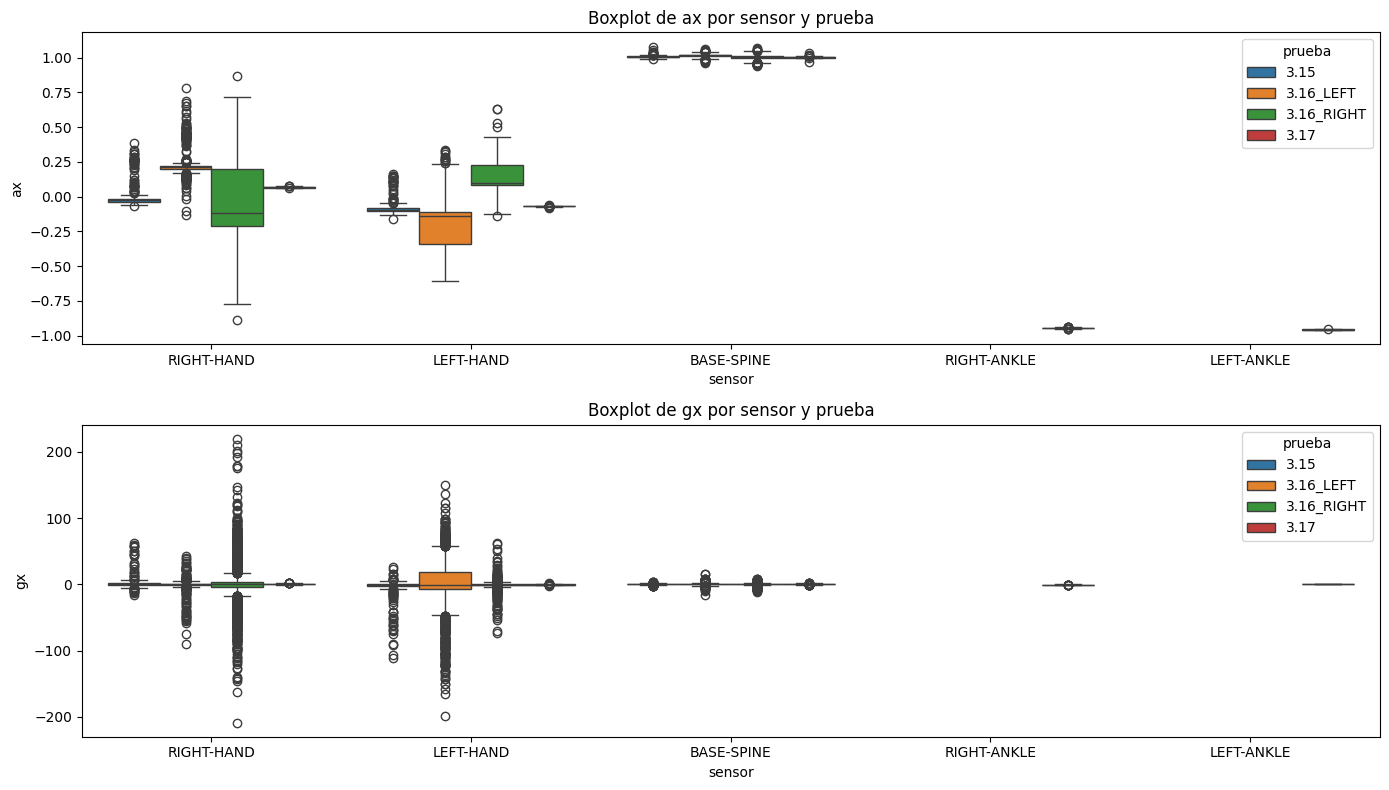

In [15]:
# Análisis de outliers: boxplots de acelerómetro y giroscopio por sensor y prueba
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(14,8))
sns.boxplot(data=df_all, x='sensor', y='ax', hue='prueba', ax=axes[0])
axes[0].set_title('Boxplot de ax por sensor y prueba')
sns.boxplot(data=df_all, x='sensor', y='gx', hue='prueba', ax=axes[1])
axes[1].set_title('Boxplot de gx por sensor y prueba')
plt.tight_layout()
plt.show()

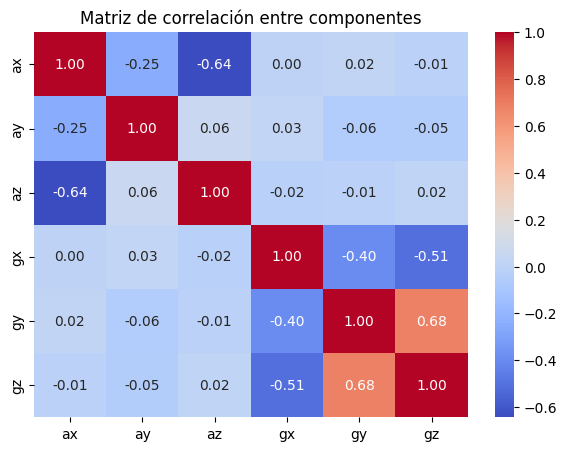

,ax,ay,az,gx,gy,gz
ax,1.000000,-0.247567,-0.643378,0.004721,0.020460,-0.013336
ay,-0.247567,1.000000,0.056750,0.027630,-0.055131,-0.047519
az,-0.643378,0.056750,1.000000,-0.021498,-0.010957,0.016666
gx,0.004721,0.027630,-0.021498,1.000000,-0.397811,-0.509745
gy,0.020460,-0.055131,-0.010957,-0.397811,1.000000,0.682260
gz,-0.013336,-0.047519,0.016666,-0.509745,0.682260,1.000000


In [16]:
# Correlación entre componentes de acelerómetro y giroscopio
df_corr = df_all[['ax','ay','az','gx','gy','gz']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre componentes')
plt.show()
df_corr

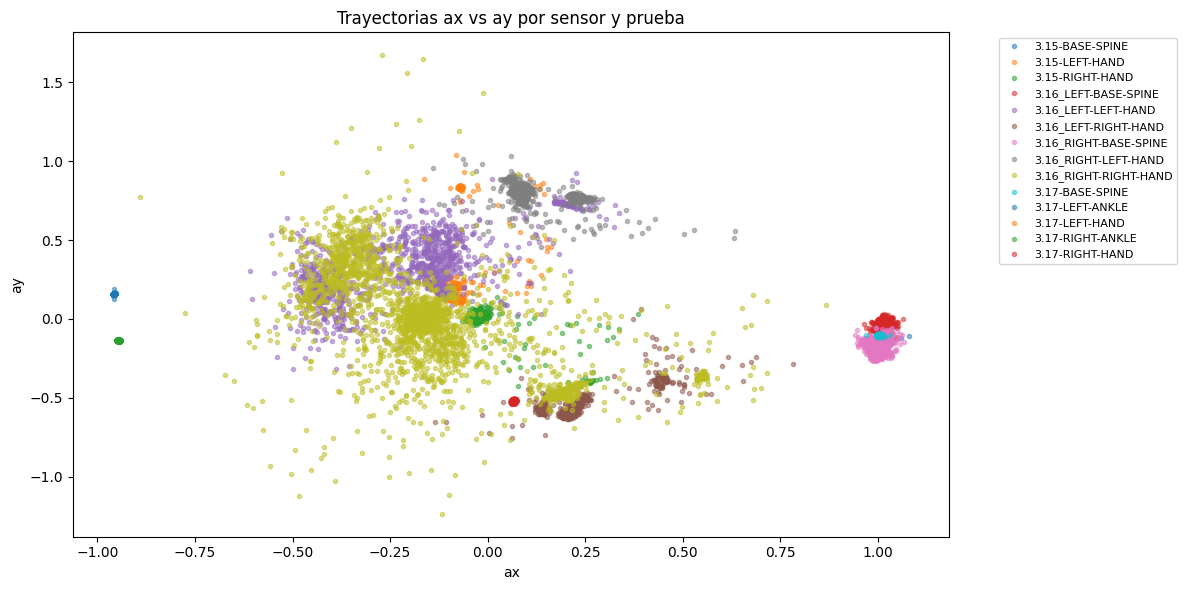

In [17]:
# Visualización adicional: trayectorias ax vs ay por sensor y prueba
plt.figure(figsize=(12,6))
for (prueba, sensor), group in df_all.groupby(['prueba','sensor']):
    plt.plot(group['ax'], group['ay'], '.', label=f'{prueba}-{sensor}', alpha=0.5)
plt.title('Trayectorias ax vs ay por sensor y prueba')
plt.xlabel('ax')
plt.ylabel('ay')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()